# Layer 4: Business-Focused Exploratory Data Analysis

## Industrial Equipment Performance & Maintenance Intelligence Analytics Platform

**Audience:** Operations Leaders, Maintenance Managers, Plant Supervisors  
**Data Source:** `machine_clean` and `machine_analytics` from SQLite database `maintenance.db`

This notebook focuses on business insight and maintenance decision making. Every analysis section is structured around a business question, SQL-driven analysis, visualization, insight, and recommendation.

In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_PATH = PROJECT_ROOT / "data" / "database" / "maintenance.db"
print(f"Database path: {DATABASE_PATH}")

Database path: C:\Users\Lavanya\Documents\Data analytics\Industrial Equipment Performance & Maintenance Intelligence Analytics Platform\data\database\maintenance.db


In [2]:
def require_database(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(
            f"Database not found at {path}. Run Layer 1 ingestion or Layer 3 cleaning before this EDA notebook."
        )

def run_sql(query: str) -> pd.DataFrame:
    with sqlite3.connect(DATABASE_PATH) as connection:
        return pd.read_sql_query(query, connection)

def validate_required_tables() -> None:
    required_tables = {"machine_clean", "machine_analytics"}
    with sqlite3.connect(DATABASE_PATH) as connection:
        existing_tables = {
            row[0]
            for row in connection.execute(
                "SELECT name FROM sqlite_master WHERE type IN ('table', 'view');"
            ).fetchall()
        }
    missing_tables = sorted(required_tables - existing_tables)
    if missing_tables:
        raise ValueError(f"Missing required database tables: {missing_tables}")

def annotate_bars(ax, values, fmt="{:.1f}", y_offset=0.01) -> None:
    max_value = max(values) if len(values) else 0
    for patch, value in zip(ax.patches, values):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + max_value * y_offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=9,
        )

require_database(DATABASE_PATH)
validate_required_tables()

In [3]:
overview_query = """
SELECT
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS total_failures,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS overall_failure_rate_percent,
    COUNT(DISTINCT machine_type) AS machine_type_count,
    ROUND(AVG(tool_wear_min), 4) AS avg_tool_wear_min,
    ROUND(AVG(operating_stress_score), 4) AS avg_operating_stress_score
FROM machine_analytics;
"""
overview_df = run_sql(overview_query)
display(overview_df)

,total_observations,total_failures,overall_failure_rate_percent,machine_type_count,avg_tool_wear_min,avg_operating_stress_score
0,10000,339,3.39,3,107.951,50.1928


## Question 1: Which Machine Type Fails Most Frequently?

### Business Question

Which machine type has the highest failure frequency and should receive the most immediate reliability attention?

### Analysis

The analysis calculates failure count and failure rate by machine type. Failure rate is more decision-useful than failure count alone because machine types may have different observation volumes.

In [4]:
q1_sql = """
SELECT
    machine_type,
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS failure_count,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent
FROM machine_analytics
GROUP BY machine_type
ORDER BY failure_rate_percent DESC;
"""
machine_type_failure_df = run_sql(q1_sql)
display(machine_type_failure_df)

,machine_type,total_observations,failure_count,failure_rate_percent
0,L,6000,235,3.9167
1,M,2997,83,2.7694
2,H,1003,21,2.0937


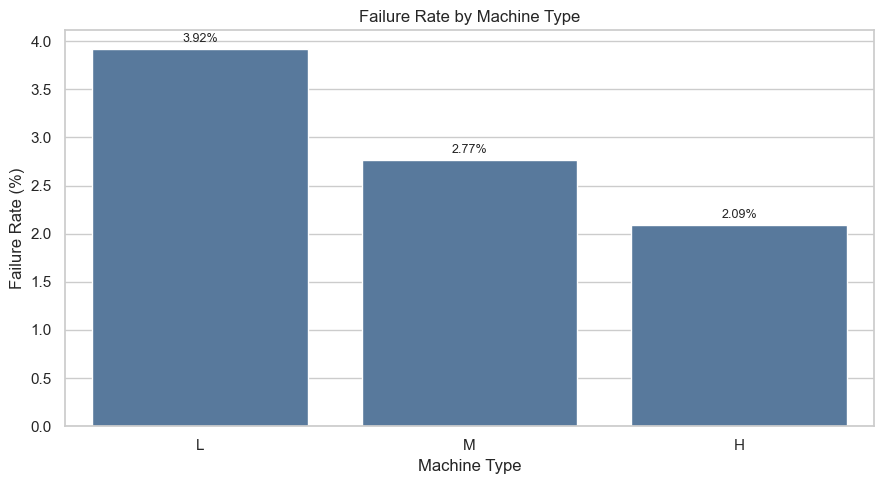

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=machine_type_failure_df,
    x="machine_type",
    y="failure_rate_percent",
    ax=ax,
    color="#4C78A8",
)
annotate_bars(ax, machine_type_failure_df["failure_rate_percent"].tolist(), fmt="{:.2f}%")
ax.set_title("Failure Rate by Machine Type")
ax.set_xlabel("Machine Type")
ax.set_ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

In [6]:
highest_failure_type = machine_type_failure_df.iloc[0]
print("Business Interpretation")
print(
    f"Machine type {highest_failure_type['machine_type']} has the highest failure rate at "
    f"{highest_failure_type['failure_rate_percent']:.2f}% across "
    f"{int(highest_failure_type['total_observations']):,} observations."
)
print("Recommendation")
print(
    "Prioritize this machine type for reliability review, compare its operating conditions against lower-failure types, "
    "and use it as the first segment for preventive maintenance policy refinement."
)

Business Interpretation
Machine type L has the highest failure rate at 3.92% across 6,000 observations.
Recommendation
Prioritize this machine type for reliability review, compare its operating conditions against lower-failure types, and use it as the first segment for preventive maintenance policy refinement.


## Question 2: Which Operating Conditions Are Most Associated With Machine Failures?

### Business Question

Which operating signals show meaningful differences between failed and non-failed observations?

### Analysis

This section compares failed versus non-failed observations across temperature, torque, speed, mechanical power, and operating stress. The purpose is to identify operating conditions that may require limits, alerts, or maintenance intervention.

In [7]:
q2_sql = """
SELECT
    CASE WHEN machine_failure = 1 THEN 'Failed' ELSE 'Non-Failed' END AS machine_status,
    COUNT(*) AS observation_count,
    ROUND(AVG(air_temperature_k), 4) AS avg_air_temperature_k,
    ROUND(AVG(process_temperature_k), 4) AS avg_process_temperature_k,
    ROUND(AVG(temperature_difference_k), 4) AS avg_temperature_difference_k,
    ROUND(AVG(torque_nm), 4) AS avg_torque_nm,
    ROUND(AVG(rotational_speed_rpm), 4) AS avg_rotational_speed_rpm,
    ROUND(AVG(mechanical_power_watts), 4) AS avg_mechanical_power_watts,
    ROUND(AVG(operating_stress_score), 4) AS avg_operating_stress_score
FROM machine_analytics
GROUP BY machine_failure
ORDER BY machine_failure DESC;
"""
condition_comparison_df = run_sql(q2_sql)
display(condition_comparison_df)

,machine_status,observation_count,avg_air_temperature_k,avg_process_temperature_k,avg_temperature_difference_k,avg_torque_nm,avg_rotational_speed_rpm,avg_mechanical_power_watts,avg_operating_stress_score
0,Failed,339,300.8864,310.2903,9.4038,50.1681,1496.4867,7282.8195,56.6044
1,Non-Failed,9661,299.9740,309.9956,10.0216,39.6297,1540.2600,6244.5475,49.9678


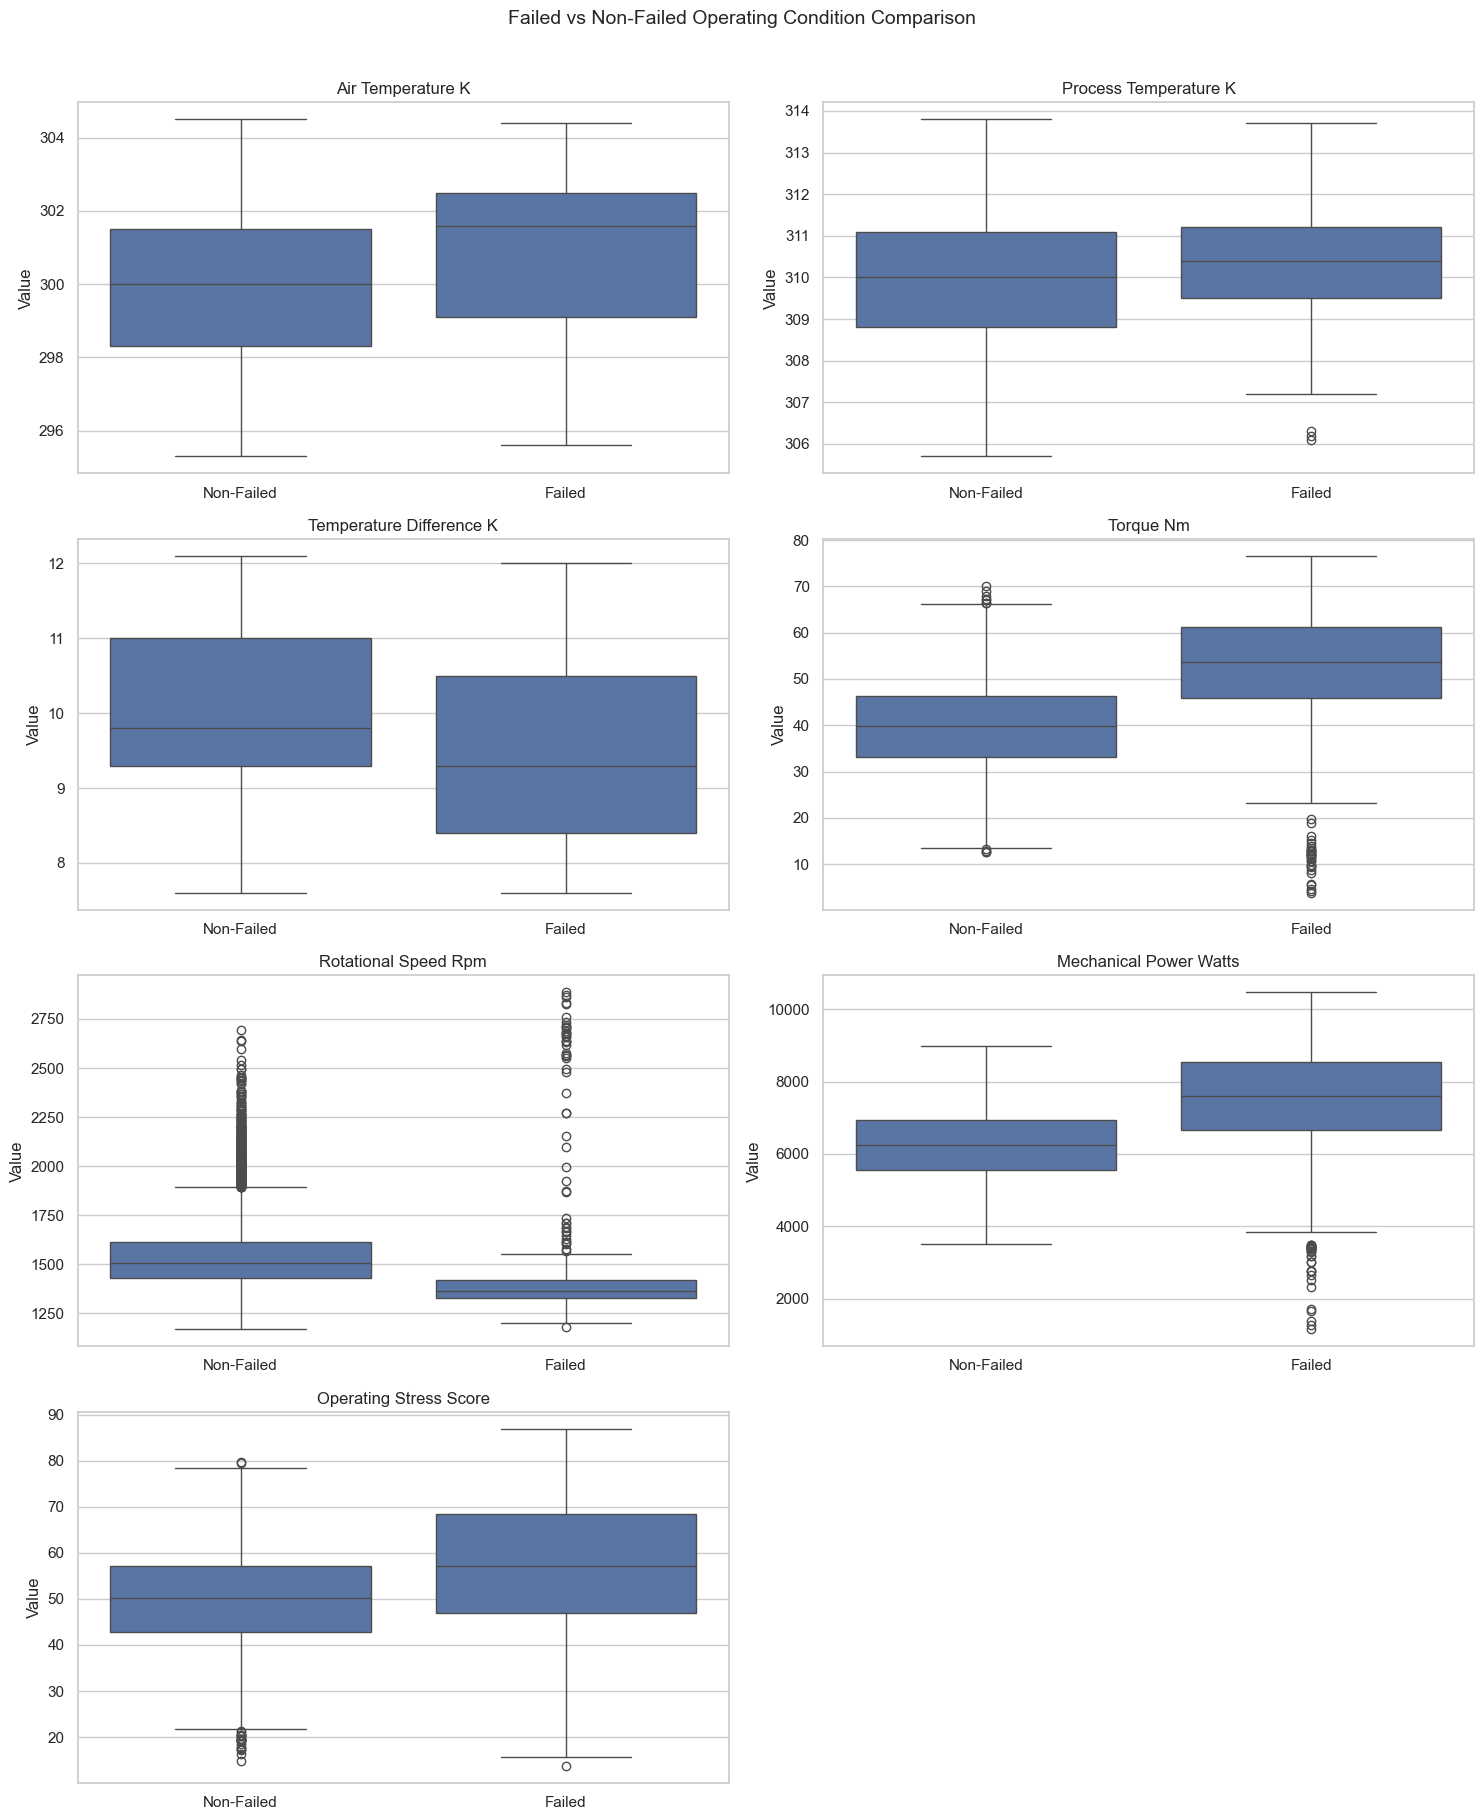

In [8]:
condition_detail_sql = """
SELECT
    CASE WHEN machine_failure = 1 THEN 'Failed' ELSE 'Non-Failed' END AS machine_status,
    air_temperature_k,
    process_temperature_k,
    temperature_difference_k,
    torque_nm,
    rotational_speed_rpm,
    mechanical_power_watts,
    operating_stress_score
FROM machine_analytics;
"""
condition_detail_df = run_sql(condition_detail_sql)

condition_columns = [
    "air_temperature_k",
    "process_temperature_k",
    "temperature_difference_k",
    "torque_nm",
    "rotational_speed_rpm",
    "mechanical_power_watts",
    "operating_stress_score",
]

condition_long_df = condition_detail_df.melt(
    id_vars="machine_status",
    value_vars=condition_columns,
    var_name="operating_condition",
    value_name="value",
)

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for index, column in enumerate(condition_columns):
    sns.boxplot(
        data=condition_detail_df,
        x="machine_status",
        y=column,
        ax=axes[index],
        order=["Non-Failed", "Failed"],
    )
    axes[index].set_title(column.replace("_", " ").title())
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Value")

axes[-1].axis("off")
plt.suptitle("Failed vs Non-Failed Operating Condition Comparison", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
failed_values = condition_comparison_df.loc[condition_comparison_df["machine_status"] == "Failed"].iloc[0]
non_failed_values = condition_comparison_df.loc[condition_comparison_df["machine_status"] == "Non-Failed"].iloc[0]

difference_rows = []
for column in [col for col in condition_comparison_df.columns if col.startswith("avg_")]:
    difference_rows.append(
        {
            "condition": column.replace("avg_", ""),
            "failed_average": failed_values[column],
            "non_failed_average": non_failed_values[column],
            "difference_failed_minus_non_failed": round(failed_values[column] - non_failed_values[column], 4),
        }
    )

condition_difference_df = pd.DataFrame(difference_rows).sort_values(
    "difference_failed_minus_non_failed",
    key=lambda values: values.abs(),
    ascending=False,
)
display(condition_difference_df)

top_condition = condition_difference_df.iloc[0]
print("Business Interpretation")
print(
    f"The largest average difference between failed and non-failed observations is in {top_condition['condition']}, "
    f"with a failed-minus-non-failed difference of {top_condition['difference_failed_minus_non_failed']:.4f}."
)
print("Recommendation")
print(
    "Use the strongest differentiating operating signals as candidates for monitoring thresholds, operator alerts, "
    "and preventive maintenance triggers. Review these signals by machine type before finalizing control limits."
)

,condition,failed_average,non_failed_average,difference_failed_minus_non_failed
5,mechanical_power_watts,7282.8195,6244.5475,1038.2720
4,rotational_speed_rpm,1496.4867,1540.2600,-43.7733
3,torque_nm,50.1681,39.6297,10.5384
6,operating_stress_score,56.6044,49.9678,6.6366
0,air_temperature_k,300.8864,299.9740,0.9124
2,temperature_difference_k,9.4038,10.0216,-0.6178
1,process_temperature_k,310.2903,309.9956,0.2947


Business Interpretation
The largest average difference between failed and non-failed observations is in mechanical_power_watts, with a failed-minus-non-failed difference of 1038.2720.
Recommendation
Use the strongest differentiating operating signals as candidates for monitoring thresholds, operator alerts, and preventive maintenance triggers. Review these signals by machine type before finalizing control limits.


## Question 3: Does Tool Wear Increase Failure Likelihood?

### Business Question

Does higher tool wear correspond to higher failure probability, and where should preventive replacement thresholds be considered?

### Analysis

This section analyzes tool wear distribution, tool wear risk categories, and failure probability by wear segment.

In [10]:
q3_sql = """
SELECT
    tool_wear_risk_level,
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS failure_count,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_probability_percent,
    ROUND(AVG(tool_wear_min), 4) AS avg_tool_wear_min,
    MIN(tool_wear_min) AS min_tool_wear_min,
    MAX(tool_wear_min) AS max_tool_wear_min
FROM machine_analytics
GROUP BY tool_wear_risk_level
ORDER BY
    CASE tool_wear_risk_level
        WHEN 'High' THEN 1
        WHEN 'Medium' THEN 2
        ELSE 3
    END;
"""
tool_wear_risk_df = run_sql(q3_sql)
display(tool_wear_risk_df)

,tool_wear_risk_level,total_observations,failure_count,failure_probability_percent,avg_tool_wear_min,min_tool_wear_min,max_tool_wear_min
0,High,801,123,15.3558,211.4757,200,253
1,Medium,3652,88,2.4096,159.6936,120,199
2,Low,5547,128,2.3076,58.9358,0,119


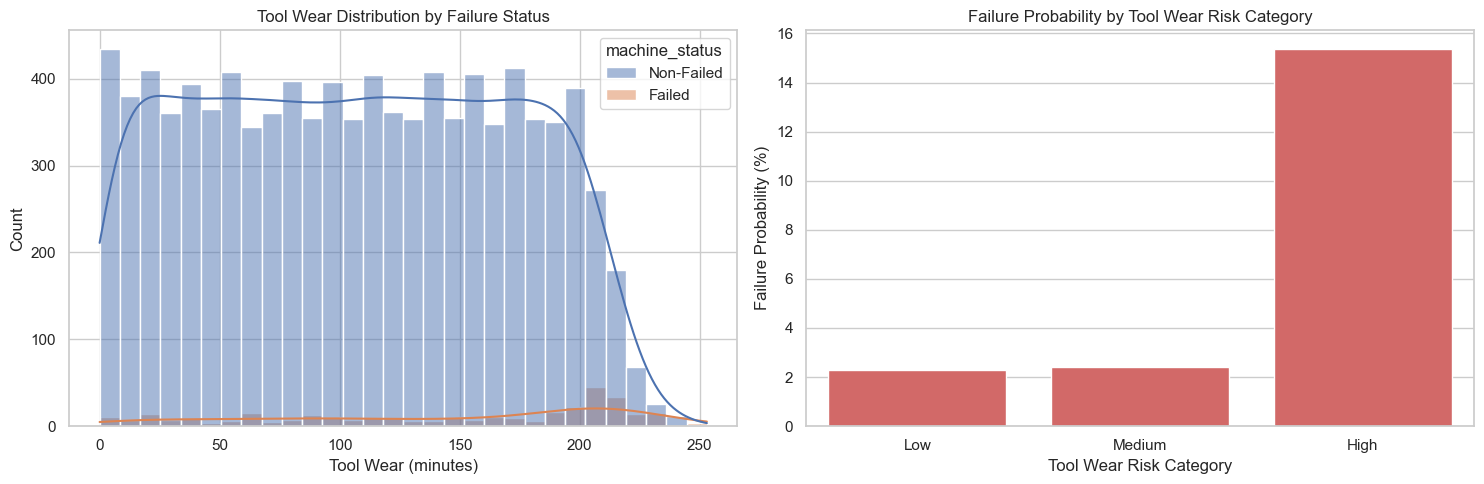

In [11]:
tool_wear_detail_df = run_sql("""
SELECT
    CASE WHEN machine_failure = 1 THEN 'Failed' ELSE 'Non-Failed' END AS machine_status,
    tool_wear_min,
    tool_wear_risk_level
FROM machine_analytics;
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=tool_wear_detail_df,
    x="tool_wear_min",
    hue="machine_status",
    kde=True,
    bins=30,
    ax=axes[0],
)
axes[0].set_title("Tool Wear Distribution by Failure Status")
axes[0].set_xlabel("Tool Wear (minutes)")

sns.barplot(
    data=tool_wear_risk_df,
    x="tool_wear_risk_level",
    y="failure_probability_percent",
    ax=axes[1],
    order=["Low", "Medium", "High"],
    color="#E45756",
)
axes[1].set_title("Failure Probability by Tool Wear Risk Category")
axes[1].set_xlabel("Tool Wear Risk Category")
axes[1].set_ylabel("Failure Probability (%)")

plt.tight_layout()
plt.show()

In [12]:
wear_segment_sql = """
WITH wear_segments AS (
    SELECT
        CASE
            WHEN tool_wear_min < 50 THEN '000-049'
            WHEN tool_wear_min < 100 THEN '050-099'
            WHEN tool_wear_min < 150 THEN '100-149'
            WHEN tool_wear_min < 200 THEN '150-199'
            ELSE '200+'
        END AS tool_wear_segment,
        machine_failure
    FROM machine_analytics
)
SELECT
    tool_wear_segment,
    COUNT(*) AS observation_count,
    SUM(machine_failure) AS failure_count,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_probability_percent
FROM wear_segments
GROUP BY tool_wear_segment
ORDER BY tool_wear_segment;
"""
wear_segment_df = run_sql(wear_segment_sql)
display(wear_segment_df)

print("Business Interpretation")
print(
    "Tool wear segments with higher failure probability indicate where replacement intervals or inspection triggers "
    "should be reviewed. The risk category view translates continuous wear into an operational decision band."
)
print("Recommendation")
print(
    "Use the High wear category as a maintenance watchlist segment and evaluate whether inspections should be scheduled "
    "before tools reach the highest observed failure-probability bands."
)

,tool_wear_segment,observation_count,failure_count,failure_probability_percent
0,000-049,2349,52,2.2137
1,050-099,2271,51,2.2457
2,100-149,2290,52,2.2707
3,150-199,2289,61,2.6649
4,200+,801,123,15.3558


Business Interpretation
Tool wear segments with higher failure probability indicate where replacement intervals or inspection triggers should be reviewed. The risk category view translates continuous wear into an operational decision band.
Recommendation
Use the High wear category as a maintenance watchlist segment and evaluate whether inspections should be scheduled before tools reach the highest observed failure-probability bands.


## Question 4: Which Failure Category Contributes Most Maintenance Burden?

### Business Question

Which failure mode creates the largest operational maintenance burden?

### Analysis

This section analyzes the five AI4I failure categories: Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, and Random Failure. A Pareto-style view identifies the categories that dominate maintenance demand.

In [13]:
q4_sql = """
WITH failure_categories AS (
    SELECT 'Tool Wear Failure' AS failure_category, SUM(twf) AS failure_count FROM machine_analytics
    UNION ALL
    SELECT 'Heat Dissipation Failure', SUM(hdf) FROM machine_analytics
    UNION ALL
    SELECT 'Power Failure', SUM(pwf) FROM machine_analytics
    UNION ALL
    SELECT 'Overstrain Failure', SUM(osf) FROM machine_analytics
    UNION ALL
    SELECT 'Random Failure', SUM(rnf) FROM machine_analytics
), totals AS (
    SELECT SUM(failure_count) AS total_failure_modes FROM failure_categories
)
SELECT
    failure_category,
    failure_count,
    ROUND(100.0 * failure_count / NULLIF(total_failure_modes, 0), 4) AS failure_mode_share_percent
FROM failure_categories
CROSS JOIN totals
ORDER BY failure_count DESC;
"""
failure_category_df = run_sql(q4_sql)
failure_category_df["cumulative_share_percent"] = failure_category_df["failure_mode_share_percent"].cumsum()
display(failure_category_df)

,failure_category,failure_count,failure_mode_share_percent,cumulative_share_percent
0,Heat Dissipation Failure,115,30.8311,30.8311
1,Overstrain Failure,98,26.2735,57.1046
2,Power Failure,95,25.4692,82.5738
3,Tool Wear Failure,46,12.3324,94.9062
4,Random Failure,19,5.0938,100.0000


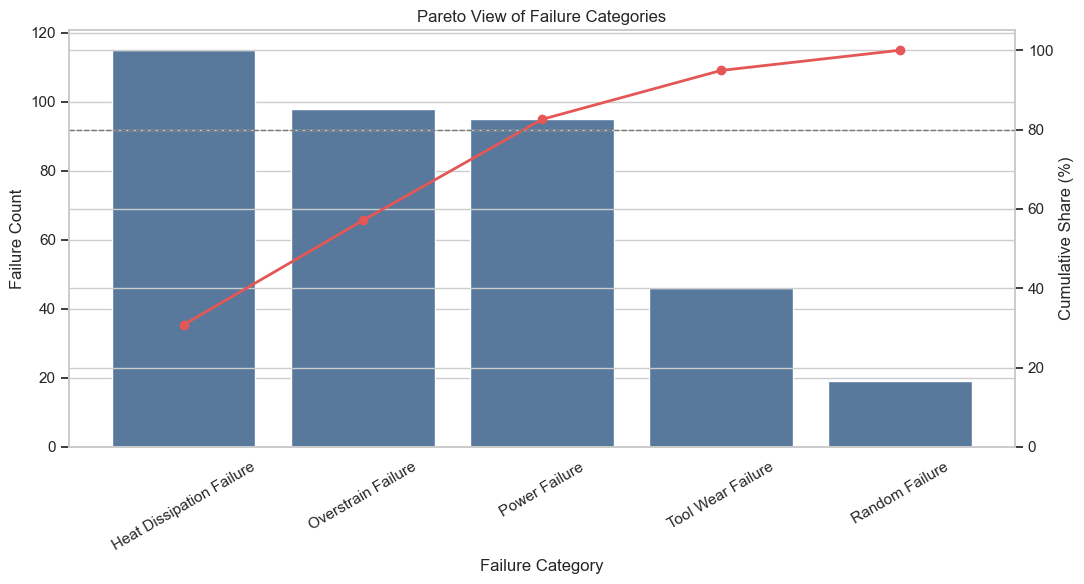

In [14]:
fig, ax1 = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=failure_category_df,
    x="failure_category",
    y="failure_count",
    ax=ax1,
    color="#4C78A8",
)
ax1.set_title("Pareto View of Failure Categories")
ax1.set_xlabel("Failure Category")
ax1.set_ylabel("Failure Count")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(
    failure_category_df["failure_category"],
    failure_category_df["cumulative_share_percent"],
    color="#E45756",
    marker="o",
    linewidth=2,
)
ax2.axhline(80, color="#777777", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative Share (%)")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [15]:
top_failure_category = failure_category_df.iloc[0]
print("Business Interpretation")
print(
    f"{top_failure_category['failure_category']} contributes the largest number of detailed failure-mode records, "
    f"representing {top_failure_category['failure_mode_share_percent']:.2f}% of categorized failure modes."
)
print("Operational Impact")
print(
    "The leading failure category is the most direct target for maintenance playbooks, technician training, spare-parts planning, "
    "and root-cause elimination. Reducing the dominant category can materially reduce maintenance workload."
)
print("Recommendation")
print(
    "Create a focused improvement plan for the top category first, then use the Pareto order to sequence the next reliability initiatives."
)

Business Interpretation
Heat Dissipation Failure contributes the largest number of detailed failure-mode records, representing 30.83% of categorized failure modes.
Operational Impact
The leading failure category is the most direct target for maintenance playbooks, technician training, spare-parts planning, and root-cause elimination. Reducing the dominant category can materially reduce maintenance workload.
Recommendation
Create a focused improvement plan for the top category first, then use the Pareto order to sequence the next reliability initiatives.


## Question 5: Which Operating Stress Profiles Create the Highest Maintenance Risk?

### Business Question

Which combinations of operating stress and mechanical power are most associated with failure risk?

### Analysis

This section segments operating stress, compares mechanical power, and identifies high-risk profiles by failure rate.

In [16]:
q5_sql = """
WITH risk_segments AS (
    SELECT
        CASE
            WHEN operating_stress_score >= 75 THEN 'Critical Stress'
            WHEN operating_stress_score >= 50 THEN 'High Stress'
            WHEN operating_stress_score >= 25 THEN 'Moderate Stress'
            ELSE 'Low Stress'
        END AS operating_stress_segment,
        CASE
            WHEN mechanical_power_watts >= 9000 THEN 'High Power'
            WHEN mechanical_power_watts >= 6000 THEN 'Medium Power'
            ELSE 'Low Power'
        END AS power_segment,
        machine_failure,
        mechanical_power_watts,
        operating_stress_score
    FROM machine_analytics
)
SELECT
    operating_stress_segment,
    power_segment,
    COUNT(*) AS observation_count,
    SUM(machine_failure) AS failure_count,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent,
    ROUND(AVG(mechanical_power_watts), 4) AS avg_mechanical_power_watts,
    ROUND(AVG(operating_stress_score), 4) AS avg_operating_stress_score
FROM risk_segments
GROUP BY operating_stress_segment, power_segment
ORDER BY failure_rate_percent DESC, observation_count DESC;
"""
stress_profile_df = run_sql(q5_sql)
display(stress_profile_df)

,operating_stress_segment,power_segment,observation_count,failure_count,failure_rate_percent,avg_mechanical_power_watts,avg_operating_stress_score
0,High Stress,High Power,53,53,100.0000,9319.9276,64.2692
1,Critical Stress,High Power,11,11,100.0000,9560.7718,79.2630
2,Critical Stress,Medium Power,49,22,44.8980,8156.7500,77.2616
3,Low Stress,Low Power,68,12,17.6471,4130.8717,21.2835
4,High Stress,Medium Power,3924,129,3.2875,7048.0354,58.8361
5,Moderate Stress,Medium Power,1999,65,3.2516,6675.3678,43.9979
6,High Stress,Low Power,1083,20,1.8467,5492.9276,55.4743
7,Moderate Stress,Low Power,2813,27,0.9598,5178.9383,40.3531


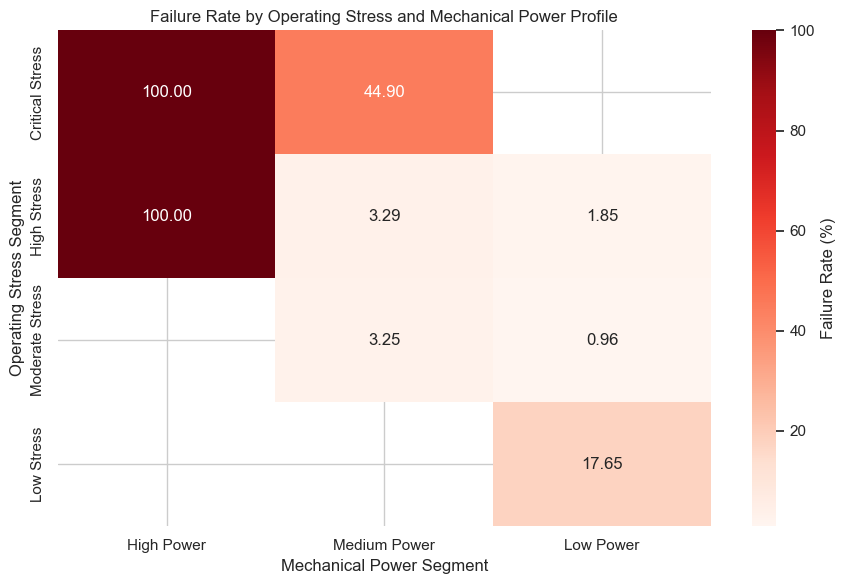

In [17]:
stress_heatmap_df = stress_profile_df.pivot_table(
    index="operating_stress_segment",
    columns="power_segment",
    values="failure_rate_percent",
    aggfunc="mean",
).reindex(index=["Critical Stress", "High Stress", "Moderate Stress", "Low Stress"], columns=["High Power", "Medium Power", "Low Power"])

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(stress_heatmap_df, annot=True, fmt=".2f", cmap="Reds", ax=ax, cbar_kws={"label": "Failure Rate (%)"})
ax.set_title("Failure Rate by Operating Stress and Mechanical Power Profile")
ax.set_xlabel("Mechanical Power Segment")
ax.set_ylabel("Operating Stress Segment")
plt.tight_layout()
plt.show()

In [18]:
highest_risk_profile = stress_profile_df.iloc[0]
print("Business Interpretation")
print(
    f"The highest-risk profile is {highest_risk_profile['operating_stress_segment']} with "
    f"{highest_risk_profile['power_segment']}, showing a failure rate of "
    f"{highest_risk_profile['failure_rate_percent']:.2f}%."
)
print("Recommendation")
print(
    "Treat this profile as a priority watch condition. Machines entering this segment should trigger inspection, "
    "operator review, or maintenance scheduling before failure rates escalate."
)

Business Interpretation
The highest-risk profile is High Stress with High Power, showing a failure rate of 100.00%.
Recommendation
Treat this profile as a priority watch condition. Machines entering this segment should trigger inspection, operator review, or maintenance scheduling before failure rates escalate.


## Question 6: Which Machine Groups Should Receive Preventive Maintenance Priority?

### Business Question

Which machine groups should be prioritized for preventive maintenance based on failure rate, tool wear risk, and operating stress?

### Analysis

This section creates a priority matrix that classifies machine groups into High Priority, Medium Priority, and Low Priority.

In [19]:
q6_sql = """
WITH grouped AS (
    SELECT
        machine_type,
        tool_wear_risk_level,
        CASE
            WHEN operating_stress_score >= 75 THEN 'Critical Stress'
            WHEN operating_stress_score >= 50 THEN 'High Stress'
            WHEN operating_stress_score >= 25 THEN 'Moderate Stress'
            ELSE 'Low Stress'
        END AS operating_stress_segment,
        COUNT(*) AS observation_count,
        SUM(machine_failure) AS failure_count,
        ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent,
        ROUND(AVG(operating_stress_score), 4) AS avg_operating_stress_score
    FROM machine_analytics
    GROUP BY machine_type, tool_wear_risk_level, operating_stress_segment
)
SELECT
    machine_type,
    tool_wear_risk_level,
    operating_stress_segment,
    observation_count,
    failure_count,
    failure_rate_percent,
    avg_operating_stress_score,
    CASE
        WHEN failure_rate_percent >= 5
          OR tool_wear_risk_level = 'High'
          OR operating_stress_segment IN ('Critical Stress', 'High Stress') THEN 'High Priority'
        WHEN failure_rate_percent >= 2
          OR tool_wear_risk_level = 'Medium'
          OR operating_stress_segment = 'Moderate Stress' THEN 'Medium Priority'
        ELSE 'Low Priority'
    END AS preventive_maintenance_priority
FROM grouped
ORDER BY
    CASE preventive_maintenance_priority
        WHEN 'High Priority' THEN 1
        WHEN 'Medium Priority' THEN 2
        ELSE 3
    END,
    failure_rate_percent DESC,
    avg_operating_stress_score DESC;
"""
priority_matrix_df = run_sql(q6_sql)
display(priority_matrix_df)

,machine_type,tool_wear_risk_level,operating_stress_segment,observation_count,failure_count,failure_rate_percent,avg_operating_stress_score,preventive_maintenance_priority
0,M,Low,Critical Stress,1,1,100.0000,75.8011,High Priority
1,L,High,Critical Stress,15,13,86.6667,77.9959,High Priority
2,M,High,Critical Stress,7,5,71.4286,78.7003,High Priority
3,L,Medium,Critical Stress,21,11,52.3810,77.1106,High Priority
4,M,Medium,Critical Stress,10,3,30.0000,77.9928,High Priority
5,M,Low,Low Stress,20,6,30.0000,20.9541,High Priority
6,L,High,High Stress,419,75,17.8998,62.0380,High Priority
7,L,Low,Low Stress,44,6,13.6364,21.3949,High Priority
8,H,High,High Stress,65,8,12.3077,62.2221,High Priority
9,M,High,Moderate Stress,38,4,10.5263,45.7812,High Priority


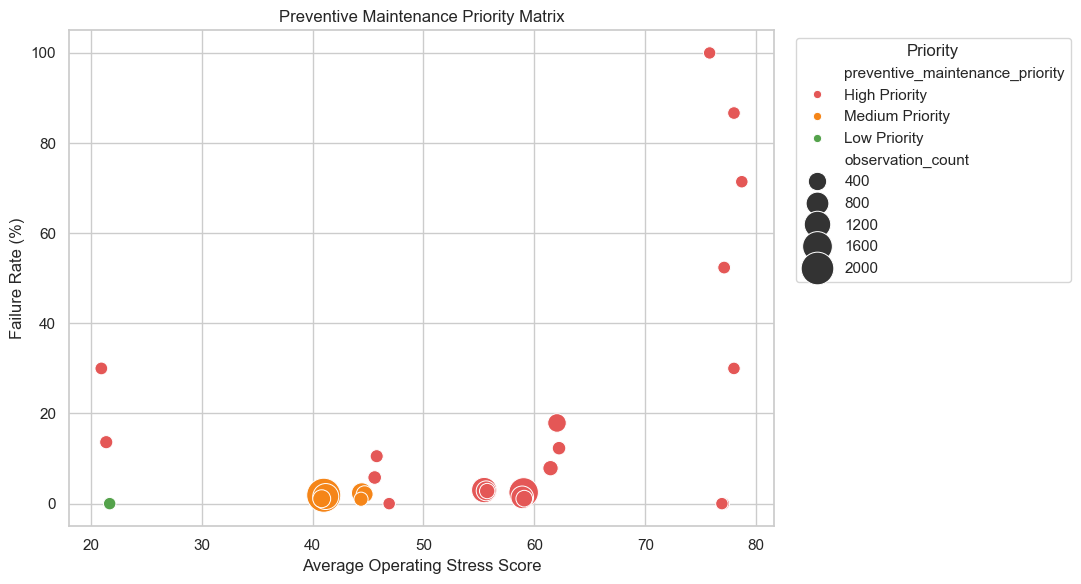

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
priority_colors = {"High Priority": "#E45756", "Medium Priority": "#F58518", "Low Priority": "#54A24B"}
sns.scatterplot(
    data=priority_matrix_df,
    x="avg_operating_stress_score",
    y="failure_rate_percent",
    size="observation_count",
    hue="preventive_maintenance_priority",
    palette=priority_colors,
    sizes=(80, 600),
    ax=ax,
)
ax.set_title("Preventive Maintenance Priority Matrix")
ax.set_xlabel("Average Operating Stress Score")
ax.set_ylabel("Failure Rate (%)")
ax.legend(title="Priority", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
priority_counts = priority_matrix_df.groupby("preventive_maintenance_priority", as_index=False).agg(
    group_count=("machine_type", "count"),
    total_observations=("observation_count", "sum"),
    total_failures=("failure_count", "sum"),
)
display(priority_counts)

high_priority_groups = priority_matrix_df.loc[
    priority_matrix_df["preventive_maintenance_priority"] == "High Priority"
].head(5)

print("Business Interpretation")
print(
    f"The matrix identifies {len(high_priority_groups)} leading high-priority group(s) in the top view. "
    "These groups combine elevated failure rate, high wear, or high stress exposure."
)
print("Recommendation")
print(
    "Use High Priority groups for near-term preventive maintenance scheduling. Medium Priority groups should receive monitoring, "
    "while Low Priority groups can remain on standard maintenance cadence unless conditions change."
)

,preventive_maintenance_priority,group_count,total_observations,total_failures
0,High Priority,21,5298,255
1,Low Priority,1,4,0
2,Medium Priority,6,4698,84


Business Interpretation
The matrix identifies 5 leading high-priority group(s) in the top view. These groups combine elevated failure rate, high wear, or high stress exposure.
Recommendation
Use High Priority groups for near-term preventive maintenance scheduling. Medium Priority groups should receive monitoring, while Low Priority groups can remain on standard maintenance cadence unless conditions change.


## Question 7: What Patterns Emerge Before Failure Events?

### Business Question

What common operating characteristics appear in failed observations and can serve as early warning indicators?

### Analysis

The AI4I dataset is observation-based rather than timestamp-based, so this section identifies common conditions present in failure observations. These patterns are treated as early warning candidates, not time-sequenced failure precursors.

In [22]:
q7_sql = """
WITH thresholds AS (
    SELECT
        AVG(tool_wear_min) AS avg_tool_wear,
        AVG(torque_nm) AS avg_torque,
        AVG(mechanical_power_watts) AS avg_power,
        AVG(temperature_difference_k) AS avg_temp_diff,
        AVG(operating_stress_score) AS avg_stress
    FROM machine_analytics
), failed_patterns AS (
    SELECT
        CASE WHEN ma.tool_wear_min > t.avg_tool_wear THEN 1 ELSE 0 END AS above_avg_tool_wear,
        CASE WHEN ma.torque_nm > t.avg_torque THEN 1 ELSE 0 END AS above_avg_torque,
        CASE WHEN ma.mechanical_power_watts > t.avg_power THEN 1 ELSE 0 END AS above_avg_power,
        CASE WHEN ma.temperature_difference_k > t.avg_temp_diff THEN 1 ELSE 0 END AS above_avg_temp_diff,
        CASE WHEN ma.operating_stress_score > t.avg_stress THEN 1 ELSE 0 END AS above_avg_stress
    FROM machine_analytics AS ma
    CROSS JOIN thresholds AS t
    WHERE ma.machine_failure = 1
)
SELECT 'Above Average Tool Wear' AS early_warning_indicator, SUM(above_avg_tool_wear) AS failed_observations_with_indicator, COUNT(*) AS total_failed_observations, ROUND(100.0 * SUM(above_avg_tool_wear) / NULLIF(COUNT(*), 0), 4) AS indicator_presence_percent FROM failed_patterns
UNION ALL
SELECT 'Above Average Torque', SUM(above_avg_torque), COUNT(*), ROUND(100.0 * SUM(above_avg_torque) / NULLIF(COUNT(*), 0), 4) FROM failed_patterns
UNION ALL
SELECT 'Above Average Mechanical Power', SUM(above_avg_power), COUNT(*), ROUND(100.0 * SUM(above_avg_power) / NULLIF(COUNT(*), 0), 4) FROM failed_patterns
UNION ALL
SELECT 'Above Average Temperature Difference', SUM(above_avg_temp_diff), COUNT(*), ROUND(100.0 * SUM(above_avg_temp_diff) / NULLIF(COUNT(*), 0), 4) FROM failed_patterns
UNION ALL
SELECT 'Above Average Operating Stress', SUM(above_avg_stress), COUNT(*), ROUND(100.0 * SUM(above_avg_stress) / NULLIF(COUNT(*), 0), 4) FROM failed_patterns
ORDER BY indicator_presence_percent DESC;
"""
early_warning_df = run_sql(q7_sql)
display(early_warning_df)

,early_warning_indicator,failed_observations_with_indicator,total_failed_observations,indicator_presence_percent
0,Above Average Torque,277,339,81.7109
1,Above Average Mechanical Power,268,339,79.0560
2,Above Average Operating Stress,233,339,68.7316
3,Above Average Tool Wear,226,339,66.6667
4,Above Average Temperature Difference,104,339,30.6785


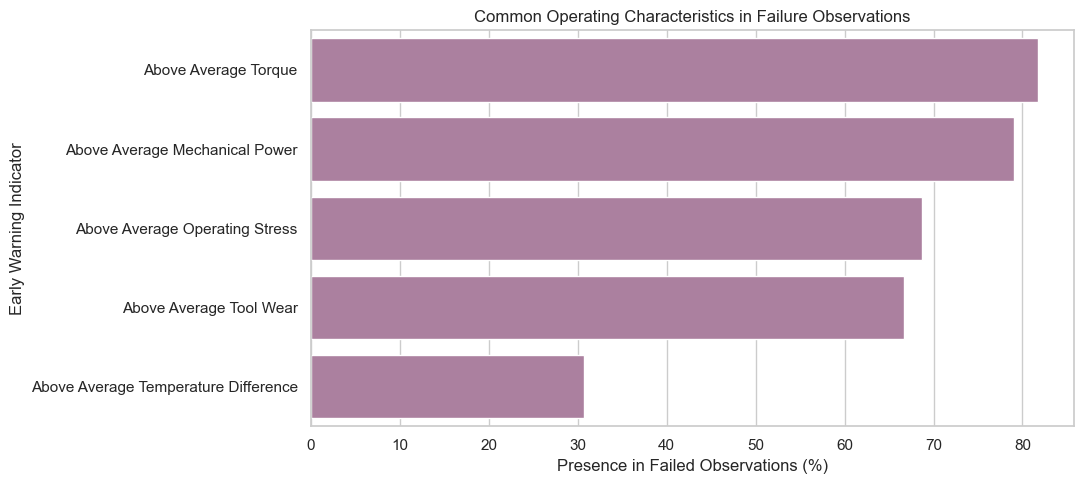

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=early_warning_df,
    x="indicator_presence_percent",
    y="early_warning_indicator",
    ax=ax,
    color="#B279A2",
)
ax.set_title("Common Operating Characteristics in Failure Observations")
ax.set_xlabel("Presence in Failed Observations (%)")
ax.set_ylabel("Early Warning Indicator")
plt.tight_layout()
plt.show()

In [24]:
top_warning = early_warning_df.iloc[0]
print("Business Interpretation")
print(
    f"The most common early warning candidate is {top_warning['early_warning_indicator']}, appearing in "
    f"{top_warning['indicator_presence_percent']:.2f}% of failed observations."
)
print("Recommendation")
print(
    "Build a maintenance watchlist around the strongest indicators and validate alert thresholds with plant engineers. "
    "These indicators should be monitored together because single-signal alerts may miss combined stress conditions."
)

Business Interpretation
The most common early warning candidate is Above Average Torque, appearing in 81.71% of failed observations.
Recommendation
Build a maintenance watchlist around the strongest indicators and validate alert thresholds with plant engineers. These indicators should be monitored together because single-signal alerts may miss combined stress conditions.


## Executive Summary

This section converts the analysis into leadership-ready findings, recommendations, and expected business impact.

In [25]:
top_findings = [
    f"Machine type {highest_failure_type['machine_type']} has the highest failure rate at {highest_failure_type['failure_rate_percent']:.2f}%.",
    f"The strongest failed vs non-failed operating difference is {top_condition['condition']} with a difference of {top_condition['difference_failed_minus_non_failed']:.4f}.",
    f"The highest-risk stress profile is {highest_risk_profile['operating_stress_segment']} with {highest_risk_profile['power_segment']} at {highest_risk_profile['failure_rate_percent']:.2f}% failure rate.",
    f"{top_failure_category['failure_category']} is the leading detailed failure category by count and contributes {top_failure_category['failure_mode_share_percent']:.2f}% of categorized failure modes.",
    f"{top_warning['early_warning_indicator']} is the most common early warning candidate in failed observations at {top_warning['indicator_presence_percent']:.2f}%.",
]

top_recommendations = [
    "Prioritize the highest-failure machine type for reliability review and preventive maintenance policy refinement.",
    "Create monitoring thresholds for the operating signals that most clearly separate failed and non-failed observations.",
    "Use High Priority groups from the preventive maintenance matrix for near-term maintenance scheduling.",
    "Launch a focused improvement plan for the dominant failure category before expanding to lower-volume categories.",
    "Build an early warning watchlist using operating stress, mechanical power, tool wear, torque, and temperature difference together.",
]

expected_business_impact = [
    "Reduced unplanned downtime through earlier identification of high-risk operating profiles.",
    "Improved maintenance prioritization by focusing attention on machine groups with the highest risk concentration.",
    "Better spare-parts and technician planning by understanding dominant failure categories.",
    "More reliable executive reporting through failure-rate and risk metrics tied directly to SQLite source tables.",
    "Stronger predictive maintenance readiness because engineered features and EDA insights identify practical model inputs.",
]

executive_summary_df = pd.DataFrame(
    {
        "Top 5 Findings": top_findings,
        "Top 5 Recommendations": top_recommendations,
        "Expected Business Impact": expected_business_impact,
    }
)
display(executive_summary_df)

,Top 5 Findings,Top 5 Recommendations,Expected Business Impact
0,Machine type L has the highest failure rate at...,Prioritize the highest-failure machine type fo...,Reduced unplanned downtime through earlier ide...
1,The strongest failed vs non-failed operating d...,Create monitoring thresholds for the operating...,Improved maintenance prioritization by focusin...
2,The highest-risk stress profile is High Stress...,Use High Priority groups from the preventive m...,Better spare-parts and technician planning by ...
3,Heat Dissipation Failure is the leading detail...,Launch a focused improvement plan for the domi...,More reliable executive reporting through fail...
4,Above Average Torque is the most common early ...,Build an early warning watchlist using operati...,Stronger predictive maintenance readiness beca...


### Executive Commentary

The maintenance analytics evidence points to a practical leadership approach: prioritize the riskiest machine groups, monitor the strongest operating warning indicators, and reduce the dominant failure categories first. The analysis is intentionally focused on decisions that plant teams can act on: maintenance scheduling, operating threshold review, reliability improvement sequencing, and dashboard monitoring.